LIBRARIES IMPORT


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('Unemployment_in_India[1].csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


DATA CLEANING

In [2]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [3]:
df.columns = df.columns.str.strip()

In [4]:
print("Missing Values:\n", df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.strftime('%B')

print("Date range:", df['Date'].min(), "to", df['Date'].max())

print("Unique regions:", df['Region'].nunique())
print(df['Region'].unique())

print("Area types:")
print(df['Area'].value_counts())
    
print("\nData is Cleaned! First some rows:")
df.head()

Missing Values:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Unique regions: 28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']
Area types:
Urban    381
Rural    359
Name: Area, dtype: int64

Data is Cleaned! First some rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


DATA EXPLORATION AND COVID-19 IMPACT

In [31]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df = df.sort_values('Date').reset_index(drop=True)

In [6]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Month'],
      dtype='object')


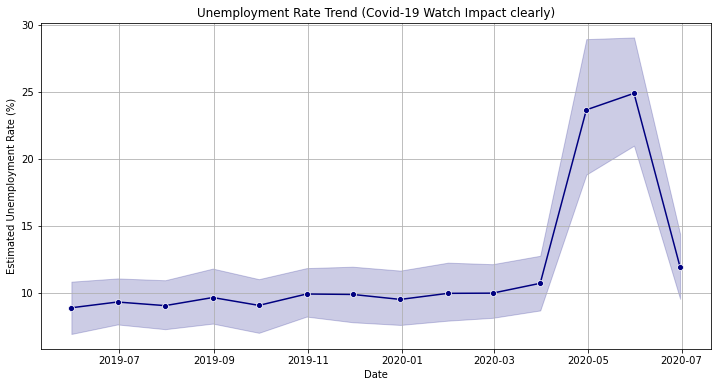

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='navy')
plt.title('Unemployment Rate Trend (Covid-19 Watch Impact clearly)')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

In [8]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Month'],
      dtype='object')


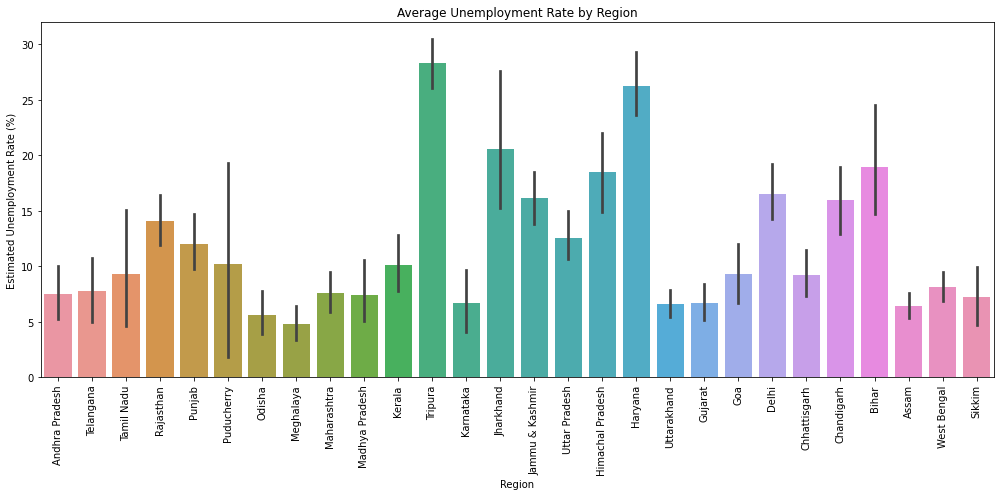

In [9]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Region', y='Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by Region')
plt.tight_layout()
plt.show()

COVID-19 IMPACT, SEASONAL TRENDS AND INSIGHTS FOR POLICY


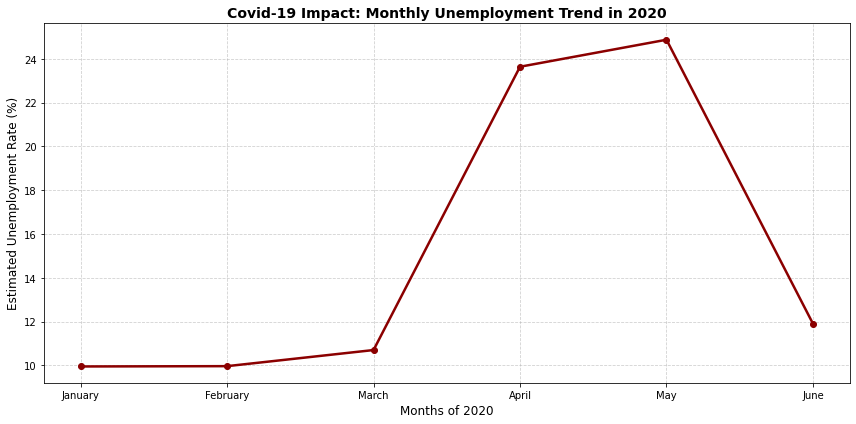

In [29]:
df.columns = df.columns.str.strip()
region_col = [col for col in df.columns if 'Region' in col or 'State' in col or 'Area' in col][0]
unemployment_col = [col for col in df.columns if 'Unemployment' in col][0]
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), dayfirst=True, errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')

df_2020 = df[df['Year'] == 2020]

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_monthly = df_2020.groupby('Month_Name')[unemployment_col].mean().reindex(months_order).dropna()

plt.figure(figsize=(12, 6))
df_monthly.plot(kind='line', marker='o', color='darkred', linewidth=2.5)

plt.title('Covid-19 Impact: Monthly Unemployment Trend in 2020', fontsize=14, fontweight='bold')
plt.xlabel('Months of 2020', fontsize=12)
plt.ylabel(unemployment_col, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [48]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = df_2020.groupby('Month_Name')[unemployment_col].mean().reindex(months_order).dropna()

highest_month = monthly_avg.idxmax()
highest_value = monthly_avg.max()

lowest_month = monthly_avg.idxmin()
lowest_value = monthly_avg.min()

print("    DATA PATTERNS & SEASONAL TRENDS   ")
print(f"Worst year of a month (Highest Unemployment): {highest_month} ({highest_value:.2f}%)")
print(f"Best year of a month (Lowest Unemployment): {lowest_month} ({lowest_value:.2f}%)")

peak_to_end_recovery = highest_value - monthly_avg.iloc[-1]
print(f"Recovery from the lockdown peak to the end of the year: {peak_to_end_recovery:.2f}      % Unemployment has decreased.")

    DATA PATTERNS & SEASONAL TRENDS   
Worst year of a month (Highest Unemployment): May (24.88%)
Best year of a month (Lowest Unemployment): January (9.95%)
Recovery from the lockdown peak to the end of the year: 12.97      % Unemployment has decreased.


POLICY INSIGHT: TOP 5 REGIONS NEEDING FINANCIAL HELP 
Hukumat ko in 5 ilakon me sabse pehle relief funds aur social help bhejni chahiye:
Region
Puducherry    75.416667
Jharkhand     57.117500
Bihar         47.247500
Tamil Nadu    40.855000
Haryana       40.295000
Name: Estimated Unemployment Rate (%), dtype: float64


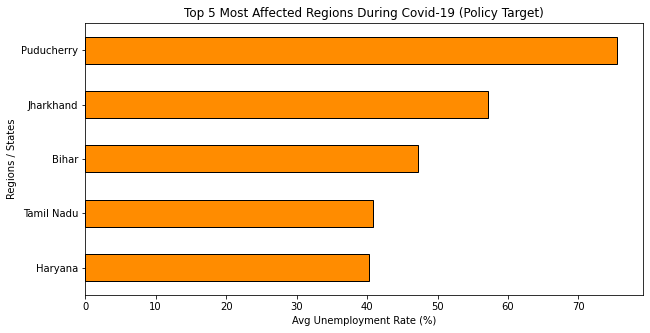

In [49]:
region_col = [col for col in df.columns if 'Region' in col or 'State' in col or 'Area' in col][0]

lockdown_data = df_2020[df_2020['Month_Name'].isin(['April', 'May'])]
top_affected_regions = lockdown_data.groupby(region_col)[unemployment_col].mean().sort_values(ascending=False).head(5)

print("POLICY INSIGHT: TOP 5 REGIONS NEEDING FINANCIAL HELP ")
print("Hukumat ko in 5 ilakon me sabse pehle relief funds aur social help bhejni chahiye:")
print(top_affected_regions)

plt.figure(figsize=(10, 5))
top_affected_regions.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Top 5 Most Affected Regions During Covid-19 (Policy Target)')
plt.xlabel('Avg Unemployment Rate (%)')
plt.ylabel('Regions / States')
plt.gca().invert_yaxis()
plt.show()

 DYNAMIC COVID-19 PERIODS 
1. Before Lockdown (January, February, March): 10.20%
2. During Lockdown (April, May): 24.26%
3. After Lockdown (June): 11.90%


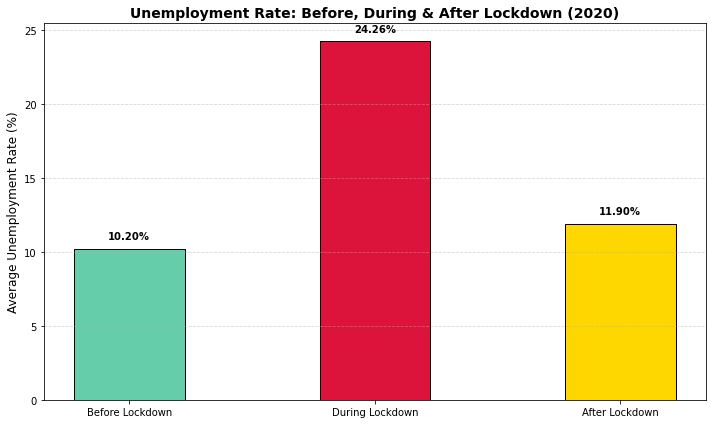

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()
unemployment_col = [col for col in df.columns if 'Unemployment' in col][0]
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), dayfirst=True, errors='coerce')
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Year'] = df['Date'].dt.year

df_2020 = df[df['Year'] == 2020]

available_months = list(df_2020['Month_Name'].unique())

# Before Lockdown 
before_months = [m for m in ['January', 'February', 'March'] if m in available_months]
before_lockdown = df_2020[df_2020['Month_Name'].isin(before_months)][unemployment_col].mean()

# During Lockdown
during_months = [m for m in ['April', 'May'] if m in available_months]
during_lockdown = df_2020[df_2020['Month_Name'].isin(during_months)][unemployment_col].mean()

# After Lockdown
after_months = [m for m in available_months if m not in before_months and m not in during_months]
after_lockdown = df_2020[df_2020['Month_Name'].isin(after_months)][unemployment_col].mean()

print(" DYNAMIC COVID-19 PERIODS ")
print(f"1. Before Lockdown ({', '.join(before_months)}): {before_lockdown:.2f}%")
print(f"2. During Lockdown ({', '.join(during_months)}): {during_lockdown:.2f}%")
print(f"3. After Lockdown ({', '.join(after_months)}): {after_lockdown:.2f}%")

plt.figure(figsize=(10, 6))
periods = ['Before Lockdown', 'During Lockdown', 'After Lockdown']
values = [before_lockdown, during_lockdown, after_lockdown]

colors = ['mediumaquamarine', 'crimson', 'gold']
bars = plt.bar(periods, values, color=colors, edgecolor='black', width=0.45)

for bar in bars:
    yval = bar.get_height()
    if not pd.isna(yval):
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Unemployment Rate: Before, During & After Lockdown (2020)', fontsize=14, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()